Этап 1: Загрузка и первичный анализ данных
1.1. Импорт основных библиотек.
1.2. Загрузка KDDTrain+.txt (в df_train) и KDDTest+.txt (в df_test).
1.3. Присвоение имен колонкам обоим датафреймам.
1.4. Первичный осмотр каждого датасета (.head(), .info(), .describe().T, .shape).

Этап 2: Очистка и исследовательский анализ данных (EDA)
2.1. Очистка (проводится для df_train и df_test отдельно или на временно объединенном для поиска общих проблем):
* Проверка на пропуски и их обработка.
* Проверка на дубликаты и их удаление (особенно важно для df_train).
2.2. Преобразование целевой переменной attack_type в многоклассовую attack_category (для df_train и df_test отдельно).
2.3. EDA (можно проводить на каждом датасете отдельно или сравнивать их):
* Анализ распределения классов attack_category в df_train и df_test.
* Анализ категориальных признаков (protocol_type, service, flag) в обоих датасетах.
* Анализ числовых признаков в обоих датасетах.
* Удаление признаков с нулевой или почти нулевой дисперсией (проверить на df_train, затем применить те же изменения к df_test).

Этап 3: Предобработка данных для машинного обучения
3.1. Выделение признаков (X) и целевой переменной (y) отдельно для обучающего и тестового наборов:
* X_train_full, y_train из df_train.
* X_test_full, y_test из df_test.
3.2. Кодирование категориальных признаков в X:
* Обучить кодировщики (LabelEncoder или OneHotEncoder) ТОЛЬКО на X_train_full.
* Применить обученные кодировщики к X_train_full (для получения X_train_encoded) и к X_test_full (для получения X_test_encoded).
3.3. Кодирование целевой переменной attack_category (если еще не сделано, например, с помощью LabelEncoder, обученного на y_train, и примененного к y_train и y_test).
3.4. Масштабирование числовых признаков:
* Обучить StandardScaler ТОЛЬКО на числовых признаках из X_train_encoded.
* Применить скейлер к X_train_encoded и X_test_encoded.
* Получаем X_train_scaled и X_test_scaled.

Этап 4: Отбор признаков (Feature Selection)
4.1. Применение методов отбора признаков ТОЛЬКО на X_train_scaled и y_train.
4.2. Выбор оптимального набора признаков.
4.3. Применение выбранного набора признаков для формирования финальных X_train и X_test.

Этап 5: Построение, обучение и оценка моделей
5.1. Для каждой модели:
* 5.1.1. Инициализация модели.
* 5.1.2. Обучение на финальных X_train, y_train. (Можно использовать кросс-валидацию на этом этапе для более надежной оценки или для подбора гиперпараметров).
* 5.1.3. Получение предсказаний на финальных X_test.
* 5.1.4. Оценка качества на y_test: classification_report, confusion_matrix, accuracy_score, ROC-AUC.
* 5.1.5. Сохранение обученной модели.
5.2. Модели для рассмотрения (Логистическая регрессия, Дерево решений, Случайный лес, XGBoost, (опционально) Наивный Байес, SVM, Нейросеть (Автоэнкодер)).
5.3. (Опционально) Подбор гиперпараметров (обучать GridSearchCV на X_train, y_train, затем лучшую модель оценивать на X_test, y_test).

Этап 6: Сравнительный анализ моделей и выводы по практической части
6.1. Сводная таблица с метриками всех моделей.
6.2. Анализ сильных и слабых сторон каждой модели на основе метрик и матрицы ошибок.
6.3. Анализ важности признаков (для моделей, которые это позволяют).
6.4. Обсуждение результатов в контексте задачи обнаружения сетевых аномалий.

# 1. Загрузка и первичный анализ данных.

## 1.1 Импорт основных библиотек.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams["figure.figsize"] = (12,7)

## 1.2 Загрузка датасетов.

In [2]:
data_test = pd.read_csv('/Users/andreyserba/Desktop/Курсач 2025/KDDTest+.txt')
data_train = pd.read_csv('/Users/andreyserba/Desktop/Курсач 2025/KDDTrain+.txt')

## 1.3 Присвоение имен колонкам обоих датасетов.

In [3]:
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root',
    'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate',
    'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count',
    'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
    'attack_type', 'difficulty_level'
]

data_train.columns = columns
data_test.columns = columns

## 1.4 Первичный осмотр датасетов.

In [4]:
print("Обучающий набор данных (KDDTrain+):")
print(f"Размеры: {data_train.shape}")
display(data_train.head())
print("\nИнформация:")
data_train.info()
print("\nСтатистики числовых признаков:")
display(data_train.describe(include=[np.number]).T)
print("\nСтатистики категориальных признаков:")
display(data_train.describe(include=['object']).T)

Обучающий набор данных (KDDTrain+):
Размеры: (125972, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack_type,difficulty_level
0,0,udp,other,SF,146,0,0,0,0,0,...,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000,normal,15
1,0,tcp,private,S0,0,0,0,0,0,0,...,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000,neptune,19
2,0,tcp,http,SF,232,8153,0,0,0,0,...,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010,normal,21
3,0,tcp,http,SF,199,420,0,0,0,0,...,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,normal,21
4,0,tcp,private,REJ,0,0,0,0,0,0,...,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000,neptune,21



Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125972 entries, 0 to 125971
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125972 non-null  int64  
 1   protocol_type                125972 non-null  object 
 2   service                      125972 non-null  object 
 3   flag                         125972 non-null  object 
 4   src_bytes                    125972 non-null  int64  
 5   dst_bytes                    125972 non-null  int64  
 6   land                         125972 non-null  int64  
 7   wrong_fragment               125972 non-null  int64  
 8   urgent                       125972 non-null  int64  
 9   hot                          125972 non-null  int64  
 10  num_failed_logins            125972 non-null  int64  
 11  logged_in                    125972 non-null  int64  
 12  num_compromised              125972 non-null 

,count,mean,std,min,25%,50%,75%,max
duration,125972.000,287.147,2604.526,0.000,0.000,0.000,0.000,42908.000
src_bytes,125972.000,45567.101,5870354.481,0.000,0.000,44.000,276.000,1379963888.000
dst_bytes,125972.000,19779.271,4021285.112,0.000,0.000,0.000,516.000,1309937401.000
land,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,1.000
wrong_fragment,125972.000,0.023,0.254,0.000,0.000,0.000,0.000,3.000
urgent,125972.000,0.000,0.014,0.000,0.000,0.000,0.000,3.000
hot,125972.000,0.204,2.150,0.000,0.000,0.000,0.000,77.000
num_failed_logins,125972.000,0.001,0.045,0.000,0.000,0.000,0.000,5.000
logged_in,125972.000,0.396,0.489,0.000,0.000,0.000,1.000,1.000
num_compromised,125972.000,0.279,23.942,0.000,0.000,0.000,0.000,7479.000



Статистики категориальных признаков:


,count,unique,top,freq
protocol_type,125972,3,tcp,102688
service,125972,70,http,40338
flag,125972,11,SF,74944
attack_type,125972,23,normal,67342


In [5]:
# print("\n\nТестовый набор данных (KDDTest+):")
# print(f"Размеры: {datatatatatatatatatatatatata_test.shape}")
# display(datatatatatatatatatatatatata_test.head())
# print("\nИнформация:")
# datatatatatatatatatatatatata_test.info()
# print("\nСтатистики числовых признаков:")
# display(datatatatatatatatatatatatata_test.describe(include=[np.number]).T)
# print("\nСтатистики категориальных признаков:")
# display(datatatatatatatatatatatatata_test.describe(include=['object']).T)

## 2. Очистка и иследовательский анализ данных (EDA).

In [6]:
data_test.isnull().sum()

duration                       0
protocol_type                  0
service                        0
flag                           0
src_bytes                      0
dst_bytes                      0
land                           0
wrong_fragment                 0
urgent                         0
hot                            0
num_failed_logins              0
logged_in                      0
num_compromised                0
root_shell                     0
su_attempted                   0
num_root                       0
num_file_creations             0
num_shells                     0
num_access_files               0
num_outbound_cmds              0
is_host_login                  0
is_guest_login                 0
count                          0
srv_count                      0
serror_rate                    0
srv_serror_rate                0
rerror_rate                    0
srv_rerror_rate                0
same_srv_rate                  0
diff_srv_rate                  0
srv_diff_h

In [7]:
print(f'Дубликатов в train_dataset: {data_train.duplicated().sum()}')
print(f'Дубликатов в test_dataset: {data_test.duplicated().sum()}')


Дубликатов в train_dataset: 0
Дубликатов в test_dataset: 0


In [8]:
# Функция для анализа уникальных значений (твоя функция)
def print_unique_values(data, column_name_list, data_name="DataFrame"):
    """Prints unique values and their counts for specific columns in the DataFrame."""
    print(f"Анализ уникальных значений для {data_name}:\n{'='*50}")
    for column_name in column_name_list:
        if column_name in data.columns:
            print(f"\nСтолбец: {column_name}\n{'-'*30}")
            unique_vals = data[column_name].unique()
            value_counts = data[column_name].value_counts()
            print(f"Уникальные значения ({len(unique_vals)}):")
            print(unique_vals)
            print(f"\nКоличество каждого значения:\n{value_counts}")
        else:
            print(f"Столбец {column_name} не найден в {data_name}")
    print(f"\n{'='*50}\n")

# Анализируем категориальные признаки и attack_type для data_train
print_unique_values(data_train, ['protocol_type', 'service', 'flag', 'attack_type'], "data_train")

# Анализируем категориальные признаки и attack_type для data_test
print_unique_values(data_test, ['protocol_type', 'service', 'flag', 'attack_type'], "data_test")

# Собираем все уникальные типы атак из обоих датасетов
all_attack_types_train = data_train['attack_type'].unique()
all_attack_types_test = data_test['attack_type'].unique()
combined_attack_types = pd.Series(list(all_attack_types_train) + list(all_attack_types_test)).unique()
print(f"Всего уникальных типов атак в обоих датасетах: {len(combined_attack_types)}")
print(combined_attack_types)

Анализ уникальных значений для data_train:

Столбец: protocol_type
------------------------------
Уникальные значения (3):
['udp' 'tcp' 'icmp']

Количество каждого значения:
protocol_type
tcp     102688
udp      14993
icmp      8291
Name: count, dtype: int64

Столбец: service
------------------------------
Уникальные значения (70):
['other' 'private' 'http' 'remote_job' 'ftp_data' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

Количество каждого значения:
service
http    

In [9]:
# Словарь для маппинга детальных типов атак в их категории
# !!! ВАЖНО: Этот словарь должен быть составлен на основе ВСЕХ уникальных значений
# из `combined_attack_types`, полученных в предыдущей ячейке !!!
# Я привожу пример, его нужно будет дополнить/скорректировать.
# Источники для маппинга: описания датасета NSL-KDD, научные статьи.

attack_categories_map = {
    # Normal
    'normal': 'normal',

    # DoS (Denial of Service)
    'neptune': 'dos',
    'smurf': 'dos',
    'pod': 'dos',
    'teardrop': 'dos',
    'land': 'dos',
    'back': 'dos',
    'apache2': 'dos',        # Из теста
    'processtable': 'dos',   # Из теста
    'mailbomb': 'dos',       # Из теста
    'udpstorm': 'dos',       # Из теста
    'worm': 'dos',           # Из теста (иногда относят к отдельной категории, но для 5 классов - к DoS или Probe)

    # Probe (Probing and Scanning)
    'ipsweep': 'probe',
    'portsweep': 'probe',
    'nmap': 'probe',
    'satan': 'probe',
    'mscan': 'probe',        # Из теста
    'saint': 'probe',        # Из теста

    # R2L (Remote to Local Access)
    'warezclient': 'r2l',
    'guess_passwd': 'r2l',
    'ftp_write': 'r2l',
    'multihop': 'r2l',
    'imap': 'r2l',
    'phf': 'r2l',
    'spy': 'r2l',
    'warezmaster': 'r2l',
    'snmpgetattack': 'r2l',  # Из теста
    'httptunnel': 'r2l',     # Из теста
    'snmpguess': 'r2l',      # Из теста
    'named': 'r2l',          # Из теста
    'sendmail': 'r2l',       # Из теста
    'xlock': 'r2l',          # Из теста
    'xsnoop': 'r2l',         # Из теста

    # U2R (User to Root Access)
    'rootkit': 'u2r',
    'buffer_overflow': 'u2r',
    'loadmodule': 'u2r',
    'perl': 'u2r',
    'ps': 'u2r',             # Из теста
    'sqlattack': 'u2r',      # Из теста
    'xterm': 'u2r'           # Из теста
}

In [10]:
# Применяем маппинг для создания нового столбца 'attack_category'
# Если тип атаки не найден в словаре, он будет помечен как 'unknown_attack'
# Это поможет выявить неклассифицированные атаки
data_train['attack_category'] = data_train['attack_type'].map(lambda x: attack_categories_map.get(x, 'unknown_attack'))
data_test['attack_category'] = data_test['attack_type'].map(lambda x: attack_categories_map.get(x, 'unknown_attack'))

# Проверим, какие категории получились и есть ли неклассифицированные
print("Категории атак в обучающем наборе после маппинга:")
train_attack_counts = data_train['attack_category'].value_counts()
print(train_attack_counts)

print("\nКатегории атак в тестовом наборе после маппинга:")
test_attack_counts = data_test['attack_category'].value_counts()
print(test_attack_counts)

Категории атак в обучающем наборе после маппинга:
attack_category
normal    67342
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64

Категории атак в тестовом наборе после маппинга:
attack_category
normal    9711
dos       7459
r2l       2885
probe     2421
u2r         67
Name: count, dtype: int64


In [11]:
# Проверка на наличие 'unknown_attack'
if 'unknown_attack' in train_attack_counts.index or 'unknown_attack' in test_attack_counts.index:
    print("\nВНИМАНИЕ: Обнаружены атаки, не попавшие в словарь ('unknown_attack').")
    print("Необходимо обновить `attack_categories_map`.")
    if 'unknown_attack' in train_attack_counts.index:
        print("Неизвестные типы в data_train:")
        print(data_train[data_train['attack_category'] == 'unknown_attack']['attack_type'].value_counts())
    if 'unknown_attack' in test_attack_counts.index:
        print("Неизвестные типы в data_test:")
        print(data_test[data_test['attack_category'] == 'unknown_attack']['attack_type'].value_counts())
else:
    print("\nВсе типы атак успешно сопоставлены с категориями.")


Все типы атак успешно сопоставлены с категориями.


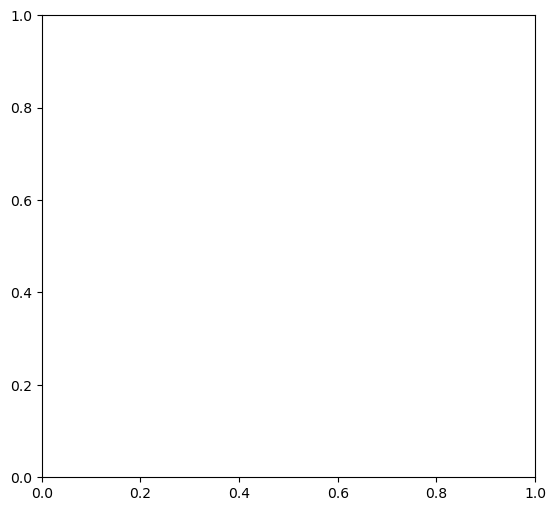

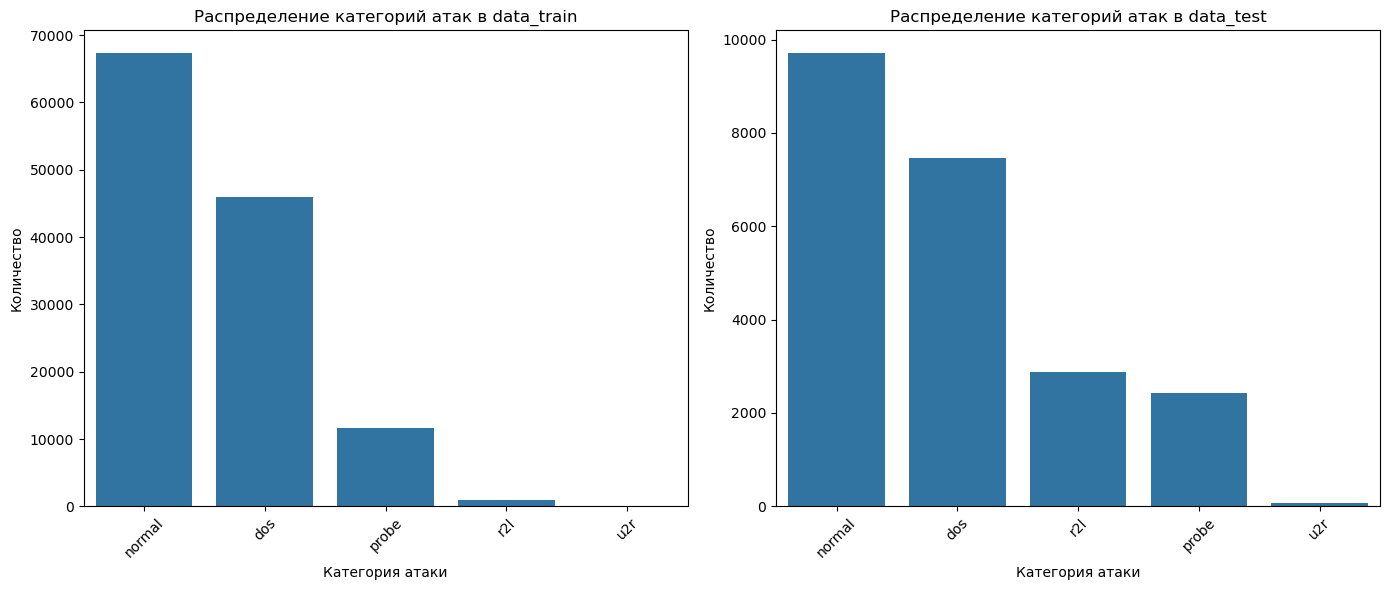

Процентное соотношение классов в data_train:
attack_category
normal   53.458
dos      36.458
probe     9.253
r2l       0.790
u2r       0.041
Name: proportion, dtype: float64

Процентное соотношение классов в data_test:
attack_category
normal   43.078
dos      33.088
r2l      12.798
probe    10.739
u2r       0.297
Name: proportion, dtype: float64


In [13]:
# Ячейка 10 (Исправленная с учетом твоих имен переменных)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
# Используем data_train как источник данных
sns.countplot(x='attack_category', data=data_train, order=data_train['attack_category'].value_counts().index)
plt.title('Распределение категорий атак в data_train') # Изменил заголовок
plt.xlabel('Категория атаки')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
# Используем data_test как источник данных
sns.countplot(x='attack_category', data=data_test, order=data_test['attack_category'].value_counts().index)
plt.title('Распределение категорий атак в data_test') # Изменил заголовок
plt.xlabel('Категория атаки')
plt.ylabel('Количество')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("Процентное соотношение классов в data_train:") # Изменил имя переменной
print(data_train['attack_category'].value_counts(normalize=True) * 100)
print("\nПроцентное соотношение классов в data_test:") # Изменил имя переменной
print(data_test['attack_category'].value_counts(normalize=True) * 100)

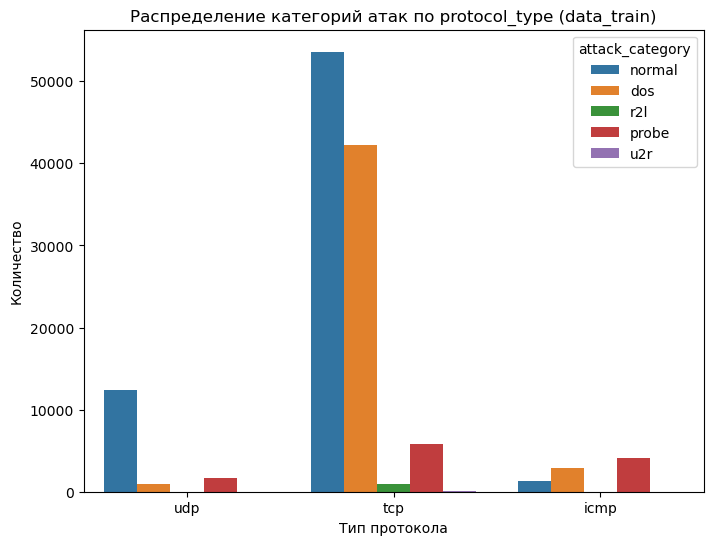

In [14]:
# Уникальные значения и их частоты уже были выведены в Ячейке 8
# Теперь визуализируем в контексте attack_category для data_train

plt.figure(figsize=(8, 6))
sns.countplot(x='protocol_type', hue='attack_category', data=data_train)
plt.title('Распределение категорий атак по protocol_type (data_train)')
plt.xlabel('Тип протокола')
plt.ylabel('Количество')
plt.show()

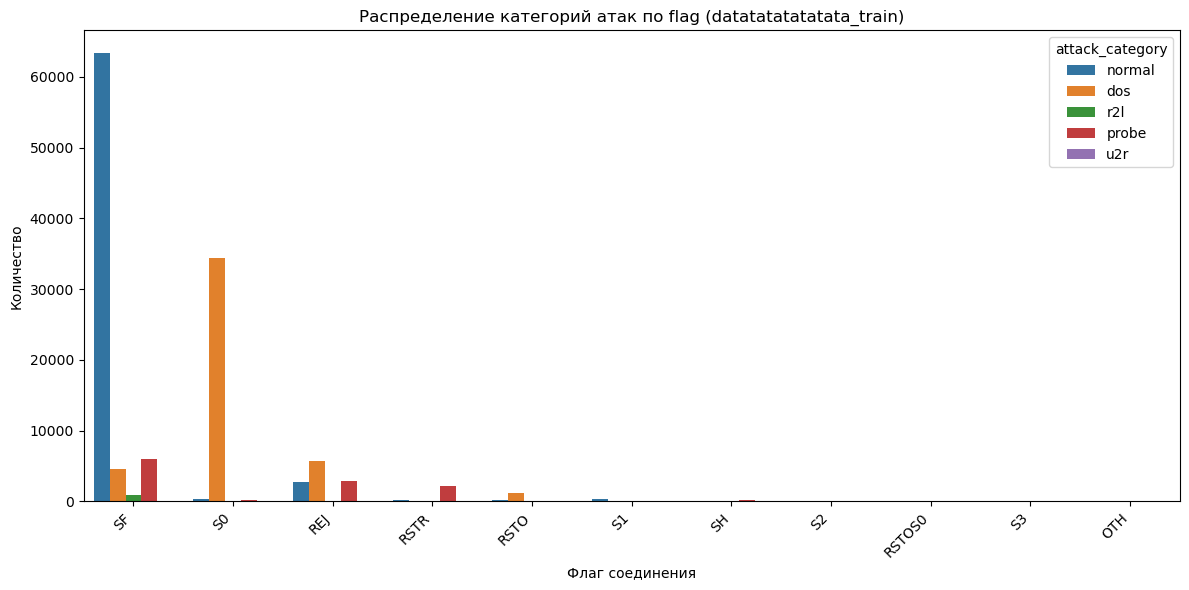

In [17]:
plt.figure(figsize=(12, 6))
sns.countplot(x='flag', hue='attack_category', data=data_train, order=data_train['flag'].value_counts().index)

plt.title('Распределение категорий атак по flag (datatatatatatata_train)')
plt.xlabel('Флаг соединения')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

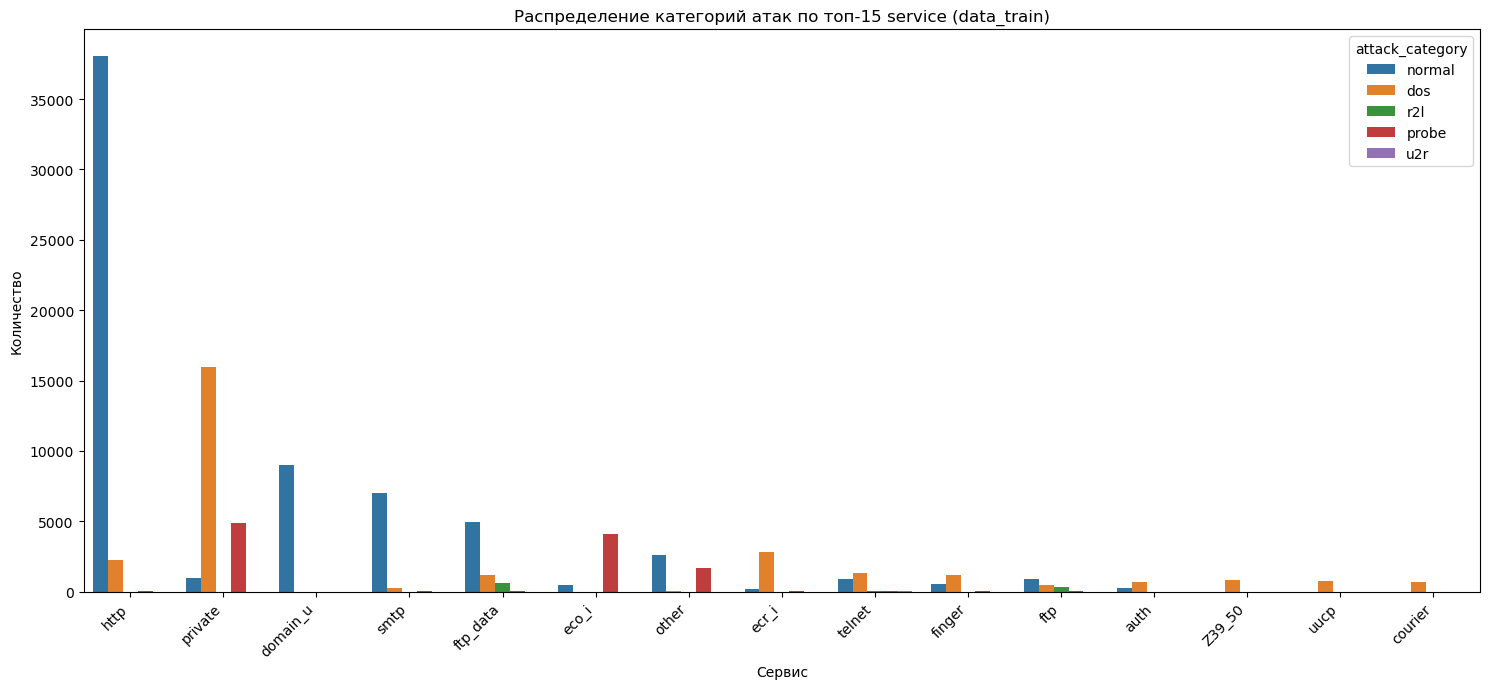

In [18]:
# Топ N сервисов по частоте
top_n_services = data_train['service'].value_counts().nlargest(15).index

data_train_top_services = data_train[data_train['service'].isin(top_n_services)]

plt.figure(figsize=(15, 7))
sns.countplot(x='service', hue='attack_category', data=data_train_top_services, order=top_n_services)
plt.title('Распределение категорий атак по топ-15 service (data_train)')
plt.xlabel('Сервис')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [19]:
# В новой ячейке перед ячейкой с histplot
features_for_log_scale_check = ['duration', 'src_bytes', 'dst_bytes', 'count', 'dst_host_srv_count']
for feature in features_for_log_scale_check:
    if feature in data_train.columns: # Проверяем, что столбец существует (на случай, если какие-то удалялись)
        print(f"Проверка столбца: {feature}")
        print(f"  Минимальное значение: {data_train[feature].min()}")
        print(f"  Количество нулей: {(data_train[feature] == 0).sum()}")
        print(f"  Количество отрицательных значений: {(data_train[feature] < 0).sum()}")
        print("-" * 30)

Проверка столбца: duration
  Минимальное значение: 0
  Количество нулей: 115954
  Количество отрицательных значений: 0
------------------------------
Проверка столбца: src_bytes
  Минимальное значение: 0
  Количество нулей: 49392
  Количество отрицательных значений: 0
------------------------------
Проверка столбца: dst_bytes
  Минимальное значение: 0
  Количество нулей: 67966
  Количество отрицательных значений: 0
------------------------------
Проверка столбца: count
  Минимальное значение: 0
  Количество нулей: 13
  Количество отрицательных значений: 0
------------------------------
Проверка столбца: dst_host_srv_count
  Минимальное значение: 0
  Количество нулей: 3
  Количество отрицательных значений: 0
------------------------------


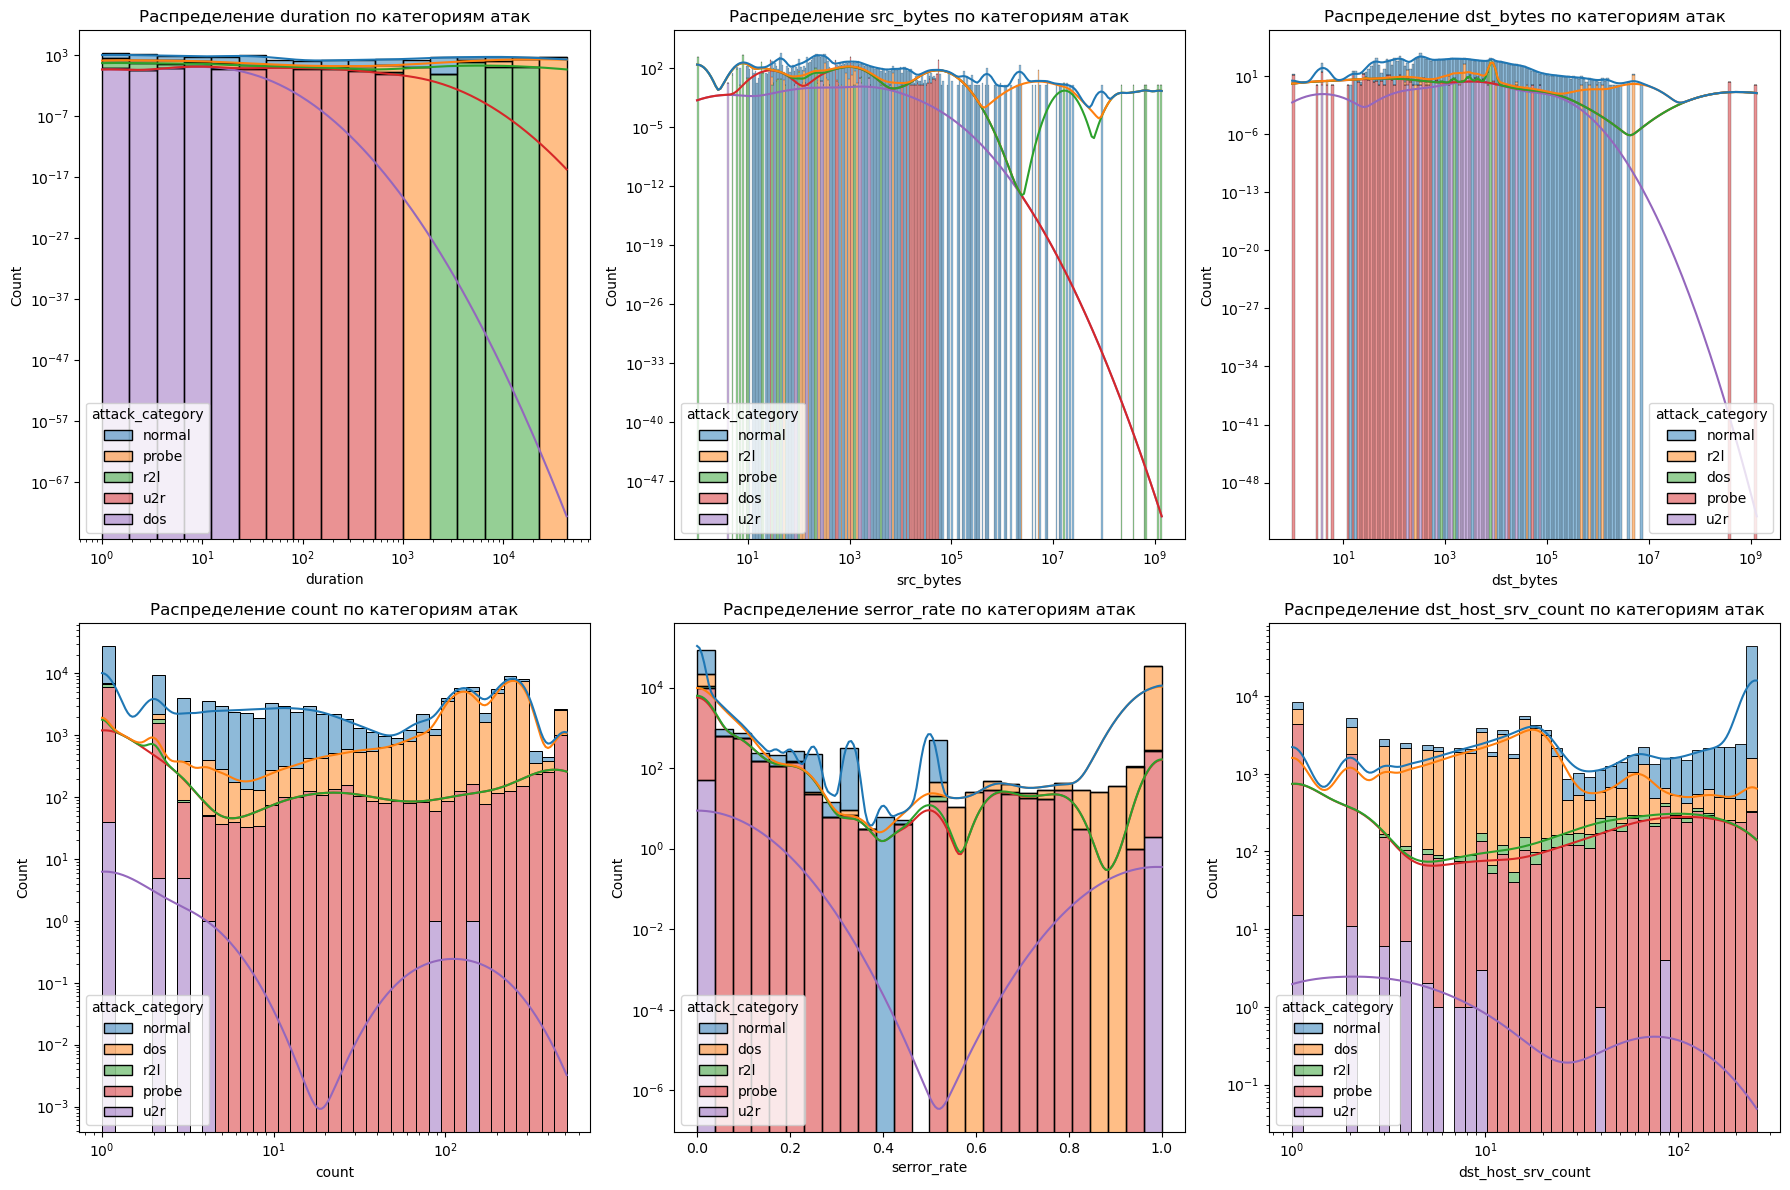

In [20]:
# Ячейка 14 (Скорректированная)
numerical_features_to_plot = ['duration', 'src_bytes', 'dst_bytes', 'count', 'serror_rate', 'dst_host_srv_count']

plt.figure(figsize=(18, 12)) # Немного увеличим размер для читаемости
for i, feature in enumerate(numerical_features_to_plot):
    plt.subplot(2, 3, i + 1)
    
    # Определяем, нужно ли использовать логарифмическую шкалу для оси X
    use_log_scale_x = not feature.endswith('_rate')
    
    if use_log_scale_x:
        # Для логарифмической шкалы X, отфильтруем нули и отрицательные значения только для этой визуализации
        data_to_plot = data_train[data_train[feature] > 0]
        if data_to_plot.empty:
            print(f"В столбце {feature} нет положительных значений, логарифмическая шкала X не будет применена.")
            sns.histplot(data=data_train, x=feature, hue='attack_category', kde=True, multiple="stack")
        else:
            sns.histplot(data=data_to_plot, x=feature, hue='attack_category', kde=True, multiple="stack", log_scale=(True, False)) # log_scale для X
    else:
        # Для _rate признаков используем линейную шкалу X
        sns.histplot(data=data_train, x=feature, hue='attack_category', kde=True, multiple="stack")
        
    plt.title(f'Распределение {feature} по категориям атак')
    
    # Логарифмируем ось Y для лучшей читаемости, если есть большой разброс в количествах
    # Это можно делать независимо от шкалы X
    # Проверим, есть ли смысл в логарифмировании Y
    if data_train[feature].value_counts().max() > 10 * data_train[feature].value_counts().min() and data_train[feature].value_counts().min() > 0 :
         if data_train[feature].value_counts().max() > 1000: # Только если есть большие значения
            plt.yscale('log')

plt.tight_layout()
plt.show()

In [21]:
# Ищем столбцы, где все значения одинаковые (стандартное отклонение равно 0)
# Делаем это на обучающем наборе
cols_to_drop = []
for col in data_train.columns:
    if data_train[col].nunique() == 1: # Если только одно уникальное значение
        cols_to_drop.append(col)

print(f"Признаки с одним уникальным значением в data_train (кандидаты на удаление): {cols_to_drop}")

if cols_to_drop:
    data_train.drop(columns=cols_to_drop, inplace=True)
    data_test.drop(columns=cols_to_drop, inplace=True) # Удаляем те же столбцы из тестового набора
    print(f"Удалены столбцы: {cols_to_drop}")
    print(f"Новые размеры data_train: {data_train.shape}")
    print(f"Новые размеры data_test: {data_test.shape}")
else:
    print("Признаков с одним уникальным значением не найдено.")

# Также проверим столбец 'difficulty_level', так как он не будет использоваться для обучения
# и может быть удален перед формированием X, y
# Или его можно удалить сейчас, если он точно не нужен для EDA
# Пока оставим его, удалим перед разделением на X и y.

Признаки с одним уникальным значением в data_train (кандидаты на удаление): ['num_outbound_cmds']
Удалены столбцы: ['num_outbound_cmds']
Новые размеры data_train: (125972, 43)
Новые размеры data_test: (22543, 43)


## Этап 3.1: Выделение признаков (X) и целевой переменной (y)

In [22]:
# Удалим столбец 'attack_type' (детальные типы атак), так как мы создали 'attack_category'
# Также удалим 'difficulty_level', так как он не будет использоваться как признак для обучения
# и столбец 'is_test', который мы добавили ранее (если ты его добавлял по моему первоначальному предложению,
# если мы идем по "Пути 1" без объединения, то его и не было).
# В нашем текущем "Пути 1" 'is_test' не создавался, так что его нет.

# Признаки для удаления из X
cols_to_remove_from_features = ['attack_type', 'difficulty_level']

# Обучающий набор
X_train_full = data_train.drop(columns=cols_to_remove_from_features + ['attack_category'])
y_train_cat = data_train['attack_category']

# Тестовый набор
X_test_full = data_test.drop(columns=cols_to_remove_from_features + ['attack_category'])
y_test_cat = data_test['attack_category']

print("Размеры X_train_full:", X_train_full.shape)
print("Размеры y_train_cat:", y_train_cat.shape)
print("Размеры X_test_full:", X_test_full.shape)
print("Размеры y_test_cat:", y_test_cat.shape)

print("\nПервые 5 строк X_train_full:")
display(X_train_full.head())
print("\nПервые 5 значений y_train_cat:")
display(y_train_cat.head())

Размеры X_train_full: (125972, 40)
Размеры y_train_cat: (125972,)
Размеры X_test_full: (22543, 40)
Размеры y_test_cat: (22543,)

Первые 5 строк X_train_full:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,udp,other,SF,146,0,0,0,0,0,...,255,1,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000
1,0,tcp,private,S0,0,0,0,0,0,0,...,255,26,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000
2,0,tcp,http,SF,232,8153,0,0,0,0,...,30,255,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010
3,0,tcp,http,SF,199,420,0,0,0,0,...,255,255,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0,tcp,private,REJ,0,0,0,0,0,0,...,255,19,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000



Первые 5 значений y_train_cat:


0    normal
1       dos
2    normal
3    normal
4       dos
Name: attack_category, dtype: object

In [23]:
categorical_features = X_train_full.select_dtypes(include=['object']).columns.tolist()
numerical_features = X_train_full.select_dtypes(include=[np.number]).columns.tolist()

print(f"Категориальные признаки ({len(categorical_features)}): {categorical_features}")
print(f"Числовые признаки ({len(numerical_features)}): {numerical_features}")

Категориальные признаки (3): ['protocol_type', 'service', 'flag']
Числовые признаки (37): ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Создаем ColumnTransformer
# remainder='passthrough' означает, что числовые признаки останутся без изменений на этом шаге
preprocessor_cat = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ],
    remainder='passthrough' # Оставляем остальные (числовые) столбцы без изменений
)

# Обучаем ColumnTransformer на X_train_full и трансформируем X_train_full
X_train_encoded_np = preprocessor_cat.fit_transform(X_train_full)

# Трансформируем X_test_full, используя обученный на трейне preprocessor_cat
X_test_encoded_np = preprocessor_cat.transform(X_test_full)

# Получаем имена новых столбцов после OneHotEncoding
# OneHotEncoder.get_feature_names_out() возвращает имена в формате "исходное_имя_столбца_значение"
# Например, "protocol_type_tcp", "protocol_type_udp"
ohe_feature_names = preprocessor_cat.named_transformers_['onehot'].get_feature_names_out(categorical_features)
new_categorical_cols = list(ohe_feature_names)

# Собираем датафреймы обратно
# Имена числовых столбцов остаются прежними
X_train_encoded = pd.DataFrame(X_train_encoded_np, columns=new_categorical_cols + numerical_features, index=X_train_full.index)
X_test_encoded = pd.DataFrame(X_test_encoded_np, columns=new_categorical_cols + numerical_features, index=X_test_full.index)


print("Размеры X_train_encoded:", X_train_encoded.shape)
print("Размеры X_test_encoded:", X_test_encoded.shape)
print("\nПервые 5 строк X_train_encoded:")
display(X_train_encoded.head())

Размеры X_train_encoded: (125972, 121)
Размеры X_test_encoded: (22543, 121)

Первые 5 строк X_train_encoded:


,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,255.000,1.000,0.000,0.600,0.880,0.000,0.000,0.000,0.000,0.000
1,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,255.000,26.000,0.100,0.050,0.000,0.000,1.000,1.000,0.000,0.000
2,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,30.000,255.000,1.000,0.000,0.030,0.040,0.030,0.010,0.000,0.010
3,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,255.000,255.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,255.000,19.000,0.070,0.070,0.000,0.000,0.000,0.000,1.000,1.000


In [25]:
from sklearn.preprocessing import LabelEncoder
label_encoder_y = LabelEncoder()

# Обучаем LabelEncoder на y_train_cat
y_train_encoded = label_encoder_y.fit_transform(y_train_cat)

# Применяем к y_test_cat
y_test_encoded = label_encoder_y.transform(y_test_cat)

# Посмотрим на соответствие меток и их кодов
print("Классы и их закодированные значения:")
for i, class_name in enumerate(label_encoder_y.classes_):
    print(f"{class_name}: {i}")

print("\nПервые 5 значений y_train_cat:", y_train_cat.head().values)
print("Первые 5 значений y_train_encoded:", y_train_encoded[:5])
print("\nУникальные значения в y_train_encoded:", np.unique(y_train_encoded))
print("Уникальные значения в y_test_encoded:", np.unique(y_test_encoded))

Классы и их закодированные значения:
dos: 0
normal: 1
probe: 2
r2l: 3
u2r: 4

Первые 5 значений y_train_cat: ['normal' 'dos' 'normal' 'normal' 'dos']
Первые 5 значений y_train_encoded: [1 0 1 1 0]

Уникальные значения в y_train_encoded: [0 1 2 3 4]
Уникальные значения в y_test_encoded: [0 1 2 3 4]


In [26]:
# numerical_features - это список исходных числовых признаков, который мы определили ранее
# Убедимся, что эти столбцы все еще существуют в X_train_encoded и X_test_encoded
# (они должны быть там, так как remainder='passthrough')

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Обучаем StandardScaler ТОЛЬКО на числовых признаках из X_train_encoded
X_train_encoded[numerical_features] = scaler.fit_transform(X_train_encoded[numerical_features])

# Применяем обученный скейлер к числовым признакам X_test_encoded
X_test_encoded[numerical_features] = scaler.transform(X_test_encoded[numerical_features])

# Переименуем для ясности (хотя можно и дальше работать с X_train_encoded/X_test_encoded)
X_train_scaled = X_train_encoded.copy()
X_test_scaled = X_test_encoded.copy()


print("Первые 5 строк X_train_scaled после масштабирования:")
display(X_train_scaled.head())
print("\nСтатистики для src_bytes в X_train_scaled (пример):")
display(X_train_scaled['src_bytes'].describe())

Первые 5 строк X_train_scaled после масштабирования:


,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_IRC,service_X11,service_Z39_50,service_aol,service_auth,service_bgp,service_courier,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.734,-1.036,-1.161,2.737,2.368,-0.289,-0.640,-0.625,-0.388,-0.376
1,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.734,-0.810,-0.938,-0.174,-0.480,-0.289,1.609,1.619,-0.388,-0.376
2,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,-1.534,1.259,1.066,-0.439,-0.383,0.066,-0.572,-0.602,-0.388,-0.345
3,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.734,1.259,1.066,-0.439,-0.480,-0.289,-0.640,-0.625,-0.388,-0.376
4,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.734,-0.873,-1.005,-0.069,-0.480,-0.289,-0.640,-0.625,2.874,2.754



Статистики для src_bytes в X_train_scaled (пример):


count   125972.000
mean        -0.000
std          1.000
min         -0.008
25%         -0.008
50%         -0.008
75%         -0.008
max        235.067
Name: src_bytes, dtype: float64

Топ-30 наиболее важных признаков по Mutual Information:
src_bytes                     0.715
diff_srv_rate                 0.508
same_srv_rate                 0.463
dst_bytes                     0.460
dst_host_diff_srv_rate        0.453
dst_host_srv_count            0.418
count                         0.414
dst_host_serror_rate          0.405
dst_host_same_srv_rate        0.404
serror_rate                   0.391
flag_SF                       0.389
dst_host_srv_serror_rate      0.381
srv_serror_rate               0.368
flag_S0                       0.367
logged_in                     0.314
dst_host_srv_diff_host_rate   0.265
dst_host_same_src_port_rate   0.237
dst_host_count                0.211
service_http                  0.195
srv_count                     0.162
srv_diff_host_rate            0.149
service_private               0.123
dst_host_rerror_rate          0.098
dst_host_srv_rerror_rate      0.083
rerror_rate                   0.082
service_eco_i                 0.073
srv_rerr

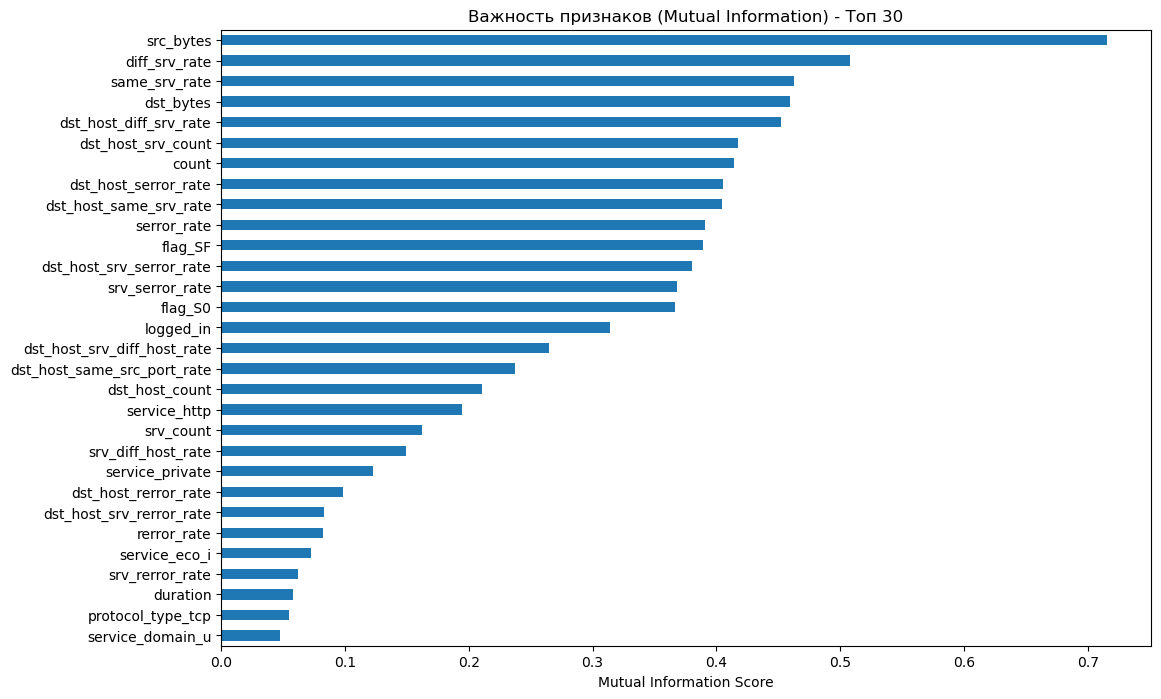


Выбрано 40 признаков:
['protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_domain_u', 'service_eco_i', 'service_ecr_i', 'service_ftp_data', 'service_http', 'service_other', 'service_private', 'service_smtp', 'flag_REJ', 'flag_RSTR', 'flag_S0', 'flag_SF', 'duration', 'src_bytes', 'dst_bytes', 'hot', 'logged_in', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

Размеры X_train_final: (125972, 40)
Размеры X_test_final: (22543, 40)

Первые 5 строк X_train_final:


,protocol_type_icmp,protocol_type_tcp,protocol_type_udp,service_domain_u,service_eco_i,service_ecr_i,service_ftp_data,service_http,service_other,service_private,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,...,0.734,-1.036,-1.161,2.737,2.368,-0.289,-0.640,-0.625,-0.388,-0.376
1,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.734,-0.810,-0.938,-0.174,-0.480,-0.289,1.609,1.619,-0.388,-0.376
2,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,...,-1.534,1.259,1.066,-0.439,-0.383,0.066,-0.572,-0.602,-0.388,-0.345
3,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000,...,0.734,1.259,1.066,-0.439,-0.480,-0.289,-0.640,-0.625,-0.388,-0.376
4,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,...,0.734,-0.873,-1.005,-0.069,-0.480,-0.289,-0.640,-0.625,2.874,2.754


In [27]:
from sklearn.feature_selection import mutual_info_classif, SelectKBest

# Рассчитываем взаимную информацию между каждым признаком в X_train_scaled и y_train_encoded
# mutual_info_classif ожидает, что y дискретный, что у нас и есть (закодированные категории)
# Для mutual_info_classif категориальные признаки (результат OHE) уже в числовом виде, что подходит.
# random_state для воспроизводимости, если алгоритм стохастический (для mutual_info_classif это не так критично, но хорошая практика)
importances = mutual_info_classif(X_train_scaled, y_train_encoded, random_state=42)

# Создаем DataFrame для наглядности
feature_importances = pd.Series(importances, index=X_train_scaled.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# Посмотрим на топ-30 наиболее важных признаков
print("Топ-30 наиболее важных признаков по Mutual Information:")
print(feature_importances.head(30))

# Визуализируем важность признаков (например, топ-30)
plt.figure(figsize=(12, 8))
feature_importances.head(30).plot(kind='barh')
plt.title('Важность признаков (Mutual Information) - Топ 30')
plt.xlabel('Mutual Information Score')
plt.gca().invert_yaxis() # Чтобы самый важный был сверху
plt.show()

# Выберем, например, топ-40 признаков с помощью SelectKBest
# Количество k можно будет настроить в дальнейшем, если потребуется
k_best_features = 40 
selector = SelectKBest(score_func=mutual_info_classif, k=k_best_features)

# Обучаем selector на X_train_scaled и y_train_encoded
X_train_selected_np = selector.fit_transform(X_train_scaled, y_train_encoded)
# Применяем обученный selector к X_test_scaled
X_test_selected_np = selector.transform(X_test_scaled)

# Получаем имена выбранных признаков
selected_feature_names = X_train_scaled.columns[selector.get_support()]
print(f"\nВыбрано {k_best_features} признаков:")
print(selected_feature_names.tolist())

# Создаем новые датафреймы с отобранными признаками
X_train_final = pd.DataFrame(X_train_selected_np, columns=selected_feature_names, index=X_train_scaled.index)
X_test_final = pd.DataFrame(X_test_selected_np, columns=selected_feature_names, index=X_test_scaled.index)

print("\nРазмеры X_train_final:", X_train_final.shape)
print("Размеры X_test_final:", X_test_final.shape)
print("\nПервые 5 строк X_train_final:")
display(X_train_final.head())

In [28]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42, multi_class='ovr', solver='liblinear', max_iter=1000) # 'ovr' для многоклассовости
lr_model.fit(X_train_final, y_train_encoded)

print("Логистическая регрессия обучена.")

# Сохранение модели
joblib.dump(lr_model, 'logistic_regression_model.joblib')
print("Модель логистической регрессии сохранена в logistic_regression_model.joblib")

Логистическая регрессия обучена.
Модель логистической регрессии сохранена в logistic_regression_model.joblib


Отчет по классификации для Логистической регрессии (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.89      0.75      0.81      7459
      normal       0.63      0.93      0.75      9711
       probe       0.88      0.65      0.75      2421
         r2l       0.94      0.01      0.02      2885
         u2r       0.50      0.01      0.03        67

    accuracy                           0.72     22543
   macro avg       0.77      0.47      0.47     22543
weighted avg       0.78      0.72      0.67     22543


Матрица ошибок для Логистической регрессии (на тестовых данных):


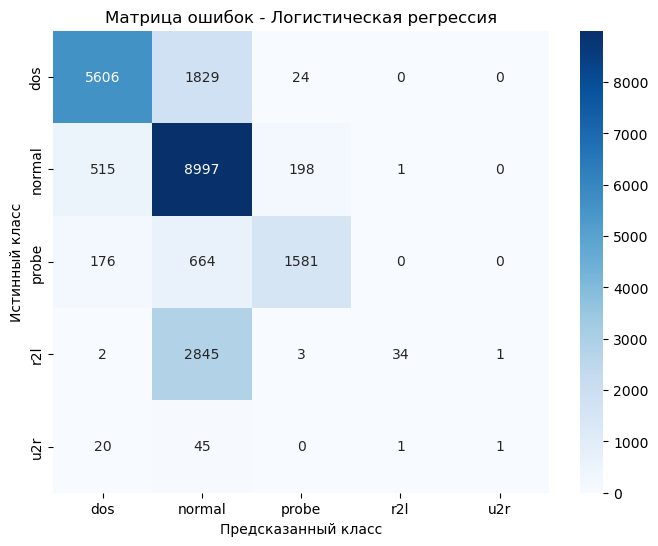


Accuracy для Логистической регрессии: 0.7195


In [29]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

y_pred_lr = lr_model.predict(X_test_final)
# y_pred_proba_lr = lr_model.predict_proba(X_test_final) # Для ROC-AUC, если понадобится

print("Отчет по классификации для Логистической регрессии (на тестовых данных):")
# Используем label_encoder_y.classes_ для получения исходных имен классов
print(classification_report(y_test_encoded, y_pred_lr, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для Логистической регрессии (на тестовых данных):")
cm_lr = confusion_matrix(y_test_encoded, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - Логистическая регрессия')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для Логистической регрессии: {accuracy_score(y_test_encoded, y_pred_lr):.4f}")

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1) # n_estimators можно подобрать, n_jobs=-1 для использования всех ядер
rf_model.fit(X_train_final, y_train_encoded)

print("Случайный лес обучен.")

joblib.dump(rf_model, 'random_forest_model.joblib')
print("Модель случайного леса сохранена в random_forest_model.joblib")

Случайный лес обучен.
Модель случайного леса сохранена в random_forest_model.joblib


Отчет по классификации для Случайного леса (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.96      0.78      0.86      7459
      normal       0.64      0.97      0.77      9711
       probe       0.85      0.59      0.70      2421
         r2l       0.97      0.03      0.06      2885
         u2r       0.67      0.06      0.11        67

    accuracy                           0.74     22543
   macro avg       0.82      0.49      0.50     22543
weighted avg       0.81      0.74      0.70     22543


Матрица ошибок для Случайного леса (на тестовых данных):


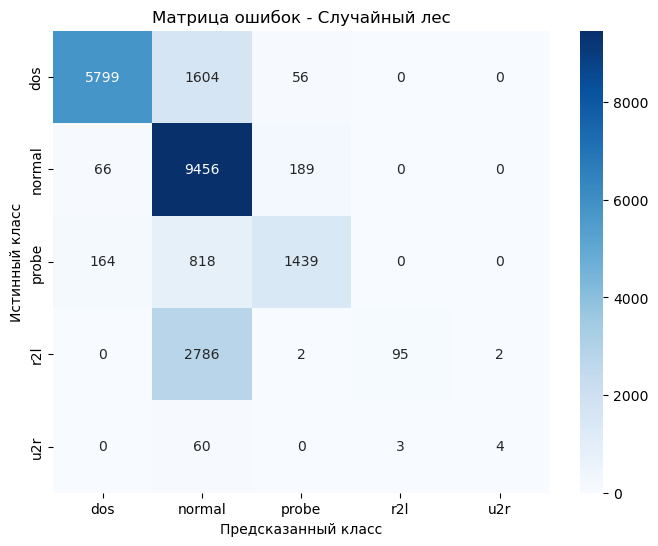


Accuracy для Случайного леса: 0.7449


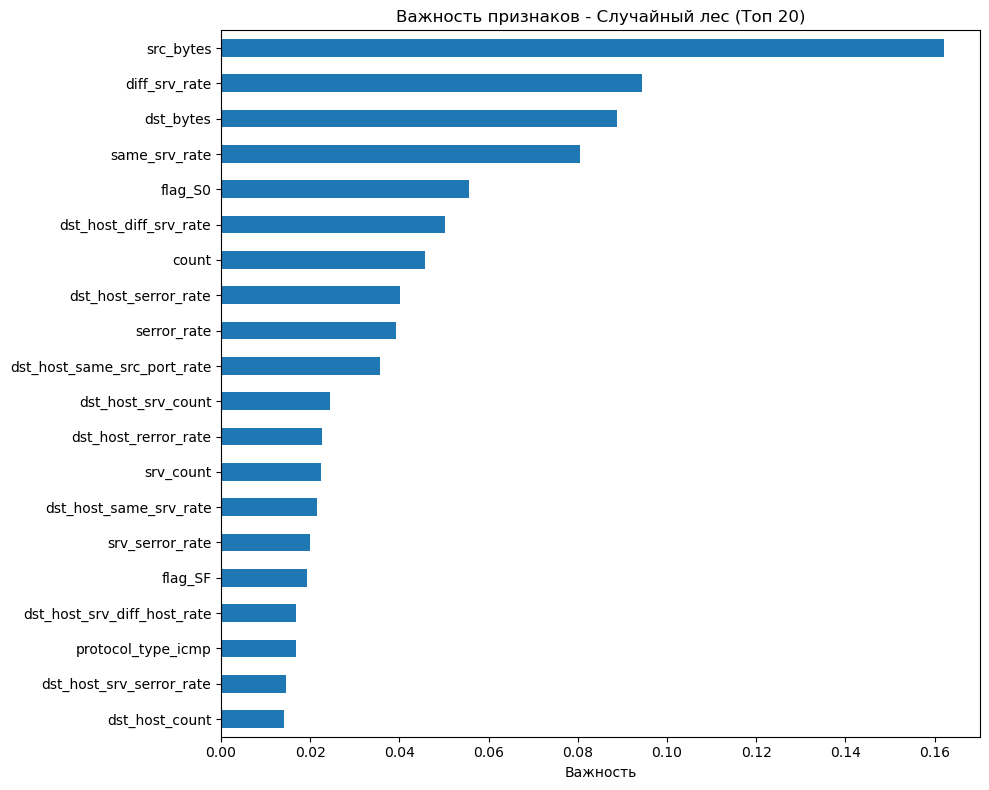

In [31]:
y_pred_rf = rf_model.predict(X_test_final)

print("Отчет по классификации для Случайного леса (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_rf, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для Случайного леса (на тестовых данных):")
cm_rf = confusion_matrix(y_test_encoded, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - Случайный лес')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для Случайного леса: {accuracy_score(y_test_encoded, y_pred_rf):.4f}")

# Важность признаков для Random Forest
if hasattr(rf_model, 'feature_importances_'):
    importances_rf = pd.Series(rf_model.feature_importances_, index=X_train_final.columns)
    importances_rf = importances_rf.sort_values(ascending=False)
    plt.figure(figsize=(10, 8)) # Увеличим размер для названий признаков
    importances_rf.head(20).plot(kind='barh') # Топ-20
    plt.title('Важность признаков - Случайный лес (Топ 20)')
    plt.xlabel('Важность')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    

In [32]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss') # use_label_encoder=False для новых версий, eval_metric для многоклассовости
xgb_model.fit(X_train_final, y_train_encoded)

print("XGBoost обучен.")

joblib.dump(xgb_model, 'xgboost_model.joblib')
print("Модель XGBoost сохранена в xgboost_model.joblib")

XGBoost обучен.
Модель XGBoost сохранена в xgboost_model.joblib


Отчет по классификации для XGBoost (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.96      0.84      0.90      7459
      normal       0.68      0.97      0.80      9711
       probe       0.83      0.63      0.72      2421
         r2l       0.99      0.10      0.19      2885
         u2r       0.57      0.12      0.20        67

    accuracy                           0.78     22543
   macro avg       0.81      0.53      0.56     22543
weighted avg       0.83      0.78      0.74     22543


Матрица ошибок для XGBoost (на тестовых данных):


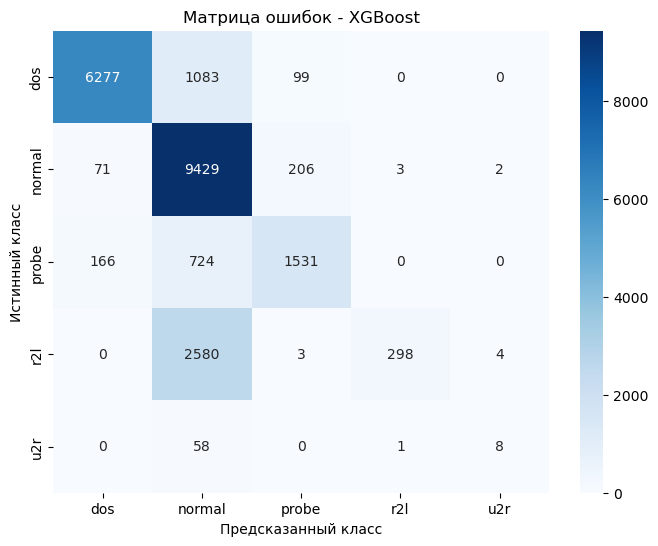


Accuracy для XGBoost: 0.7782


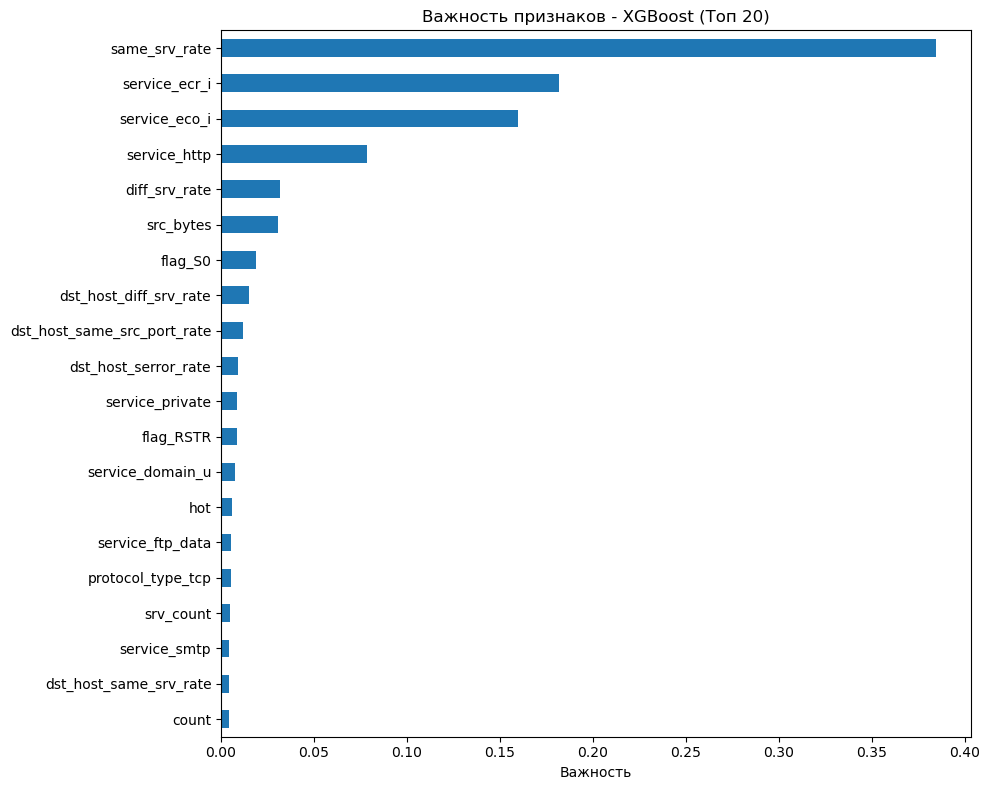

In [33]:
y_pred_xgb = xgb_model.predict(X_test_final)

print("Отчет по классификации для XGBoost (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_xgb, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для XGBoost (на тестовых данных):")
cm_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - XGBoost')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для XGBoost: {accuracy_score(y_test_encoded, y_pred_xgb):.4f}")

# Важность признаков для XGBoost
if hasattr(xgb_model, 'feature_importances_'):
    importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train_final.columns)
    importances_xgb = importances_xgb.sort_values(ascending=False)
    plt.figure(figsize=(10, 8))
    importances_xgb.head(20).plot(kind='barh')
    plt.title('Важность признаков - XGBoost (Топ 20)')
    plt.xlabel('Важность')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

Размеры до SMOTE:
1    67342
0    45927
2    11656
3      995
4       52
Name: count, dtype: int64

Размеры после SMOTE (для y_train_smote_encoded):
1    67342
0    67342
3    67342
2    67342
4    67342
Name: count, dtype: int64


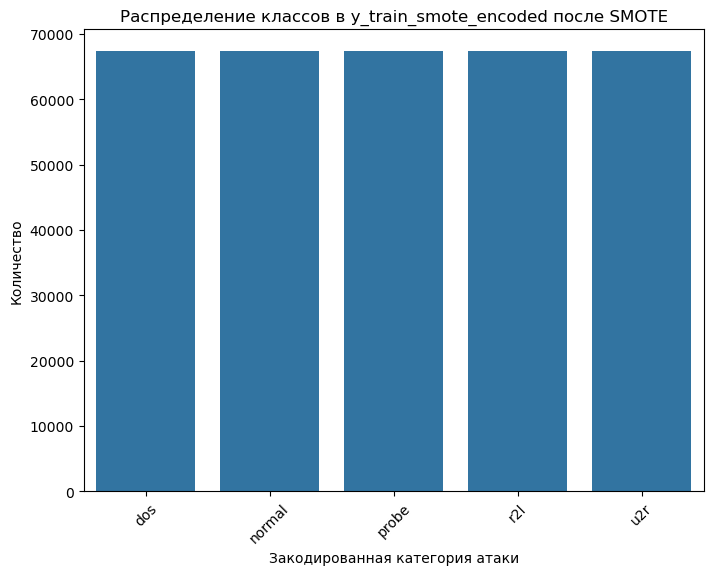

In [34]:
from imblearn.over_sampling import SMOTE

# SMOTE применяется только к обучающей выборке
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote_encoded = smote.fit_resample(X_train_final, y_train_encoded)

print("Размеры до SMOTE:")
print(pd.Series(y_train_encoded).value_counts())
print("\nРазмеры после SMOTE (для y_train_smote_encoded):")
print(pd.Series(y_train_smote_encoded).value_counts())

# Визуализируем распределение классов после SMOTE
plt.figure(figsize=(8, 6))
sns.countplot(x=y_train_smote_encoded)
plt.title('Распределение классов в y_train_smote_encoded после SMOTE')
plt.xlabel('Закодированная категория атаки')
plt.ylabel('Количество')
# Добавим метки классов на ось X
plt.xticks(ticks=range(len(label_encoder_y.classes_)), labels=label_encoder_y.classes_, rotation=45)
plt.show()

XGBoost (на данных SMOTE) обучен.
Модель XGBoost (SMOTE) сохранена в xgboost_model_smote.joblib

Отчет по классификации для XGBoost (SMOTE) (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.96      0.81      0.88      7459
      normal       0.69      0.97      0.81      9711
       probe       0.85      0.67      0.75      2421
         r2l       0.99      0.25      0.40      2885
         u2r       0.60      0.31      0.41        67

    accuracy                           0.79     22543
   macro avg       0.82      0.60      0.65     22543
weighted avg       0.84      0.79      0.77     22543


Матрица ошибок для XGBoost (SMOTE) (на тестовых данных):


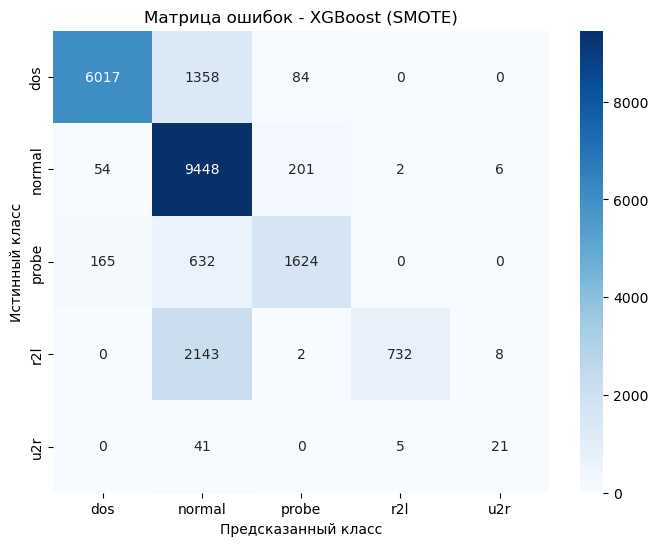


Accuracy для XGBoost (SMOTE): 0.7915


In [35]:
# Используем те же параметры для XGBoost, что и раньше, или можно подобрать новые
xgb_model_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_model_smote.fit(X_train_smote, y_train_smote_encoded)

print("XGBoost (на данных SMOTE) обучен.")

joblib.dump(xgb_model_smote, 'xgboost_model_smote.joblib')
print("Модель XGBoost (SMOTE) сохранена в xgboost_model_smote.joblib")

# Оценка на исходном (неизмененном) X_test_final и y_test_encoded
y_pred_xgb_smote = xgb_model_smote.predict(X_test_final)

print("\nОтчет по классификации для XGBoost (SMOTE) (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_xgb_smote, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для XGBoost (SMOTE) (на тестовых данных):")
cm_xgb_smote = confusion_matrix(y_test_encoded, y_pred_xgb_smote)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_smote, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - XGBoost (SMOTE)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для XGBoost (SMOTE): {accuracy_score(y_test_encoded, y_pred_xgb_smote):.4f}")

XGBoost (с взвешиванием классов) обучен.
Модель XGBoost (weighted) сохранена в xgboost_model_weighted.joblib

Отчет по классификации для XGBoost (с взвешиванием классов) (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.96      0.81      0.88      7459
      normal       0.68      0.97      0.80      9711
       probe       0.83      0.69      0.75      2421
         r2l       0.98      0.15      0.26      2885
         u2r       0.59      0.30      0.40        67

    accuracy                           0.78     22543
   macro avg       0.81      0.58      0.62     22543
weighted avg       0.83      0.78      0.75     22543


Матрица ошибок для XGBoost (с взвешиванием классов) (на тестовых данных):


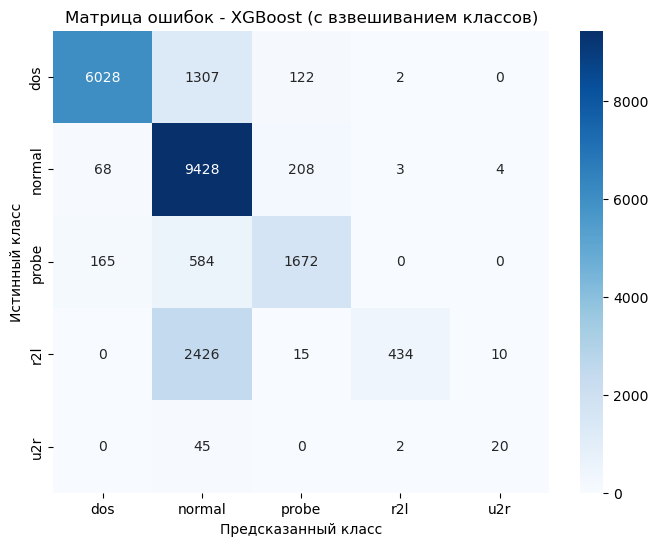


Accuracy для XGBoost (с взвешиванием классов): 0.7799


In [36]:
from sklearn.utils.class_weight import compute_sample_weight

# Рассчитаем веса для классов (обратно пропорционально частоте)
# Это нужно делать на y_train_encoded (до SMOTE)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

xgb_model_weighted = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
# Обучаем модель, передавая веса через параметр sample_weight в .fit()
# Важно: X_train_final и y_train_encoded используются здесь (не _smote)
xgb_model_weighted.fit(X_train_final, y_train_encoded, sample_weight=sample_weights)


print("XGBoost (с взвешиванием классов) обучен.")
joblib.dump(xgb_model_weighted, 'xgboost_model_weighted.joblib')
print("Модель XGBoost (weighted) сохранена в xgboost_model_weighted.joblib")

y_pred_xgb_weighted = xgb_model_weighted.predict(X_test_final)

print("\nОтчет по классификации для XGBoost (с взвешиванием классов) (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_xgb_weighted, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для XGBoost (с взвешиванием классов) (на тестовых данных):")
cm_xgb_weighted = confusion_matrix(y_test_encoded, y_pred_xgb_weighted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_weighted, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - XGBoost (с взвешиванием классов)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для XGBoost (с взвешиванием классов): {accuracy_score(y_test_encoded, y_pred_xgb_weighted):.4f}")

Наивный Байес обучен.
Модель Наивного Байеса сохранена в naive_bayes_model.joblib

Отчет по классификации для Наивного Байеса (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.80      0.77      0.79      7459
      normal       0.87      0.84      0.86      9711
       probe       0.80      0.80      0.80      2421
         r2l       0.54      0.33      0.41      2885
         u2r       0.02      0.66      0.05        67

    accuracy                           0.75     22543
   macro avg       0.61      0.68      0.58     22543
weighted avg       0.80      0.75      0.77     22543


Матрица ошибок для Наивного Байеса (на тестовых данных):


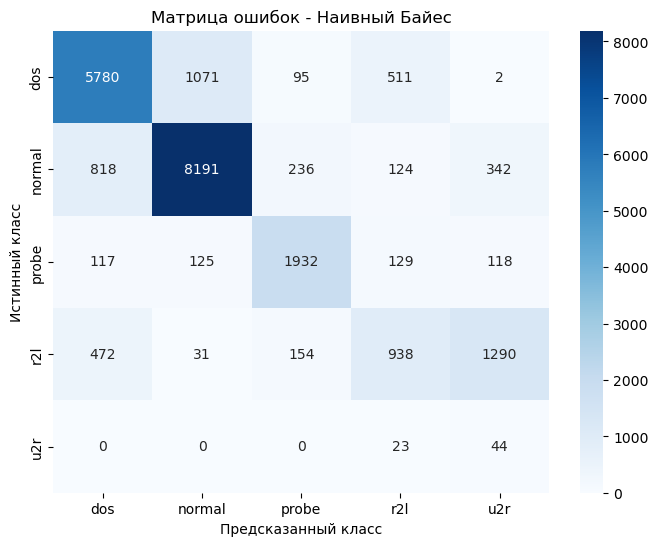


Accuracy для Наивного Байеса: 0.7490


In [37]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train_final, y_train_encoded)

print("Наивный Байес обучен.")
joblib.dump(nb_model, 'naive_bayes_model.joblib')
print("Модель Наивного Байеса сохранена в naive_bayes_model.joblib")

# Оценка
y_pred_nb = nb_model.predict(X_test_final)

print("\nОтчет по классификации для Наивного Байеса (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_nb, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для Наивного Байеса (на тестовых данных):")
cm_nb = confusion_matrix(y_test_encoded, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - Наивный Байес')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для Наивного Байеса: {accuracy_score(y_test_encoded, y_pred_nb):.4f}")

Начинаем обучение SVM (LinearSVC)... Это может занять некоторое время.
SVM (LinearSVC) обучен.
Модель SVM (LinearSVC) сохранена в svm_linear_model.joblib

Отчет по классификации для SVM (LinearSVC) (на тестовых данных):
              precision    recall  f1-score   support

         dos       0.89      0.75      0.81      7459
      normal       0.62      0.93      0.75      9711
       probe       0.87      0.63      0.73      2421
         r2l       0.93      0.01      0.03      2885
         u2r       0.50      0.01      0.03        67

    accuracy                           0.72     22543
   macro avg       0.76      0.47      0.47     22543
weighted avg       0.78      0.72      0.67     22543


Матрица ошибок для SVM (LinearSVC) (на тестовых данных):


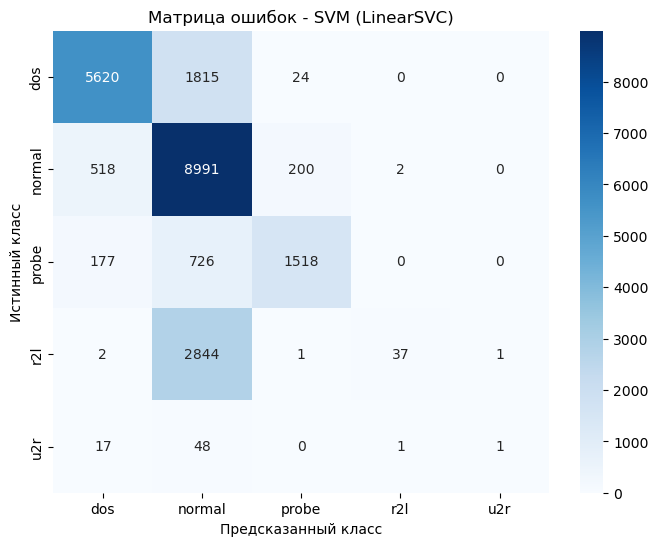


Accuracy для SVM (LinearSVC): 0.7172


In [38]:
from sklearn.svm import LinearSVC # Более быстрая альтернатива SVC для больших данных
# from sklearn.svm import SVC # Можно попробовать, но может быть долго

# LinearSVC часто требует больше итераций для сходимости
svm_model = LinearSVC(random_state=42, max_iter=2000, dual=False) # dual=False рекомендуется, когда n_samples > n_features
# Если захочешь SVC:
# svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42) # probability=True для ROC-AUC, но замедляет

print("Начинаем обучение SVM (LinearSVC)... Это может занять некоторое время.")
svm_model.fit(X_train_final, y_train_encoded)
print("SVM (LinearSVC) обучен.")

joblib.dump(svm_model, 'svm_linear_model.joblib')
print("Модель SVM (LinearSVC) сохранена в svm_linear_model.joblib")

# Оценка
y_pred_svm = svm_model.predict(X_test_final)
# Для SVC с probability=True: y_pred_proba_svm = svm_model.predict_proba(X_test_final)

print("\nОтчет по классификации для SVM (LinearSVC) (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_svm, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для SVM (LinearSVC) (на тестовых данных):")
cm_svm = confusion_matrix(y_test_encoded, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - SVM (LinearSVC)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для SVM (LinearSVC): {accuracy_score(y_test_encoded, y_pred_svm):.4f}")

In [39]:
""" #долго
from sklearn.svm import SVC # Можно попробовать, но может быть долго


# Если захочешь SVC:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42) # probability=True для ROC-AUC, но замедляет

print("Начинаем обучение SVM (LinearSVC)... Это может занять некоторое время.")
svm_model.fit(X_train_final, y_train_encoded)
print("SVM (LinearSVC) обучен.")

joblib.dump(svm_model, 'svm_linear_model.joblib')
print("Модель SVM (LinearSVC) сохранена в svm_linear_model.joblib")

# Оценка
y_pred_svm = svm_model.predict(X_test_final)
# Для SVC с probability=True: y_pred_proba_svm = svm_model.predict_proba(X_test_final)

print("\nОтчет по классификации для SVM (LinearSVC) (на тестовых данных):")
print(classification_report(y_test_encoded, y_pred_svm, target_names=label_encoder_y.classes_))

print("\nМатрица ошибок для SVM (LinearSVC) (на тестовых данных):")
cm_svm = confusion_matrix(y_test_encoded, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder_y.classes_, yticklabels=label_encoder_y.classes_)
plt.title('Матрица ошибок - SVM (LinearSVC)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для SVM (LinearSVC): {accuracy_score(y_test_encoded, y_pred_svm):.4f}") """

' #долго\nfrom sklearn.svm import SVC # Можно попробовать, но может быть долго\n\n\n# Если захочешь SVC:\nsvm_model = SVC(kernel=\'rbf\', C=1.0, gamma=\'scale\', probability=True, random_state=42) # probability=True для ROC-AUC, но замедляет\n\nprint("Начинаем обучение SVM (LinearSVC)... Это может занять некоторое время.")\nsvm_model.fit(X_train_final, y_train_encoded)\nprint("SVM (LinearSVC) обучен.")\n\njoblib.dump(svm_model, \'svm_linear_model.joblib\')\nprint("Модель SVM (LinearSVC) сохранена в svm_linear_model.joblib")\n\n# Оценка\ny_pred_svm = svm_model.predict(X_test_final)\n# Для SVC с probability=True: y_pred_proba_svm = svm_model.predict_proba(X_test_final)\n\nprint("\nОтчет по классификации для SVM (LinearSVC) (на тестовых данных):")\nprint(classification_report(y_test_encoded, y_pred_svm, target_names=label_encoder_y.classes_))\n\nprint("\nМатрица ошибок для SVM (LinearSVC) (на тестовых данных):")\ncm_svm = confusion_matrix(y_test_encoded, y_pred_svm)\nplt.figure(figsize=(8

In [40]:
# y_train_encoded: 0 - dos, 1 - normal, 2 - probe, 3 - r2l, 4 - u2r (пример, зависит от LabelEncoder)
# Нам нужно найти, какому коду соответствует 'normal'
normal_class_code = label_encoder_y.transform(['normal'])[0]
print(f"Код для класса 'normal': {normal_class_code}")

# Выбираем только нормальные данные из X_train_final для обучения автоэнкодера
X_train_normal_ae = X_train_final[y_train_encoded == normal_class_code]

print(f"Размеры данных для обучения автоэнкодера (только normal): {X_train_normal_ae.shape}")

Код для класса 'normal': 1
Размеры данных для обучения автоэнкодера (только normal): (67342, 40)


In [42]:
pip install tensorflow

  Using cached tensorflow-2.16.2-cp312-cp312-macosx_10_15_x86_64.whl.metadata (4.1 kB)
  Using cached absl_py-2.2.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-macosx_10_9_x86_64.whl.metadata (5.2 kB)
  Using cached ml_dtypes-0.3.2-cp312-cp312-macosx_10_9_universal2.whl.metadata (20 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached grpcio-1.71.0-cp312-cp312-macosx_10_14_universal2.whl.metadata (3.8 kB)
  Using cached tensorboard-2.16.2-py3-none-any.whl.metadata (1.6 kB)
  Using cached keras-3.9.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached namex-0.0.9-py3-none-any.whl.metadata (322 bytes)
  Using cached optree-0.15.0-cp312-cp312-macos

2025-05-14 23:15:17.888040: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 40)             │         5,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 40)             │         1,640 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,816 (128.19 KB)

 Trainable params: 32,816 (128.19 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.3763 - val_loss: 0.1174
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0892 - val_loss: 0.0688
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0554 - val_loss: 0.0457
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0377 - val_loss: 0.0341
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0280 - val_loss: 0.0279
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0225 - val_loss: 0.0229
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0196 - val_loss: 0.0195
Epoch 8/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0160 - val_loss: 0.0161
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0134 - val_loss: 0.0151
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0121 - val_loss: 0.0120
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0100 - val_loss: 0.0108
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 2

Автоэнкодер обучен.
Модель автоэнкодера сохранена в autoencoder_model.h5


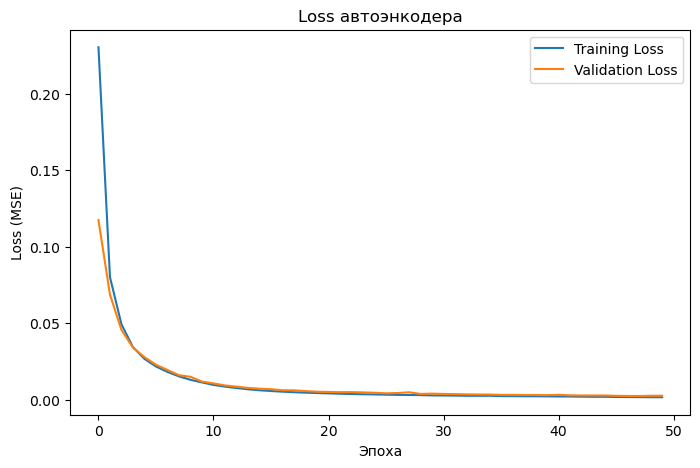

In [43]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_normal_ae.shape[1]
encoding_dim = 32 # Размерность скрытого (закодированного) представления, можно варьировать

# Энкодер
input_layer = Input(shape=(input_dim,))
encoder = Dense(128, activation="relu")(input_layer) # Уменьшаем до 128
encoder = Dense(64, activation="relu")(encoder)    # Уменьшаем до 64
encoder = Dense(encoding_dim, activation="relu")(encoder) # Сжатое представление

# Декодер
decoder = Dense(64, activation="relu")(encoder)
decoder = Dense(128, activation="relu")(decoder)
decoder = Dense(input_dim, activation='sigmoid')(decoder) # Восстанавливаем исходную размерность, sigmoid если данные были [0,1]
                                                        # или linear/relu если данные стандартизированы (как у нас)
                                                        # Для стандартизированных данных лучше 'linear' или без активации на выходе

# Пересоздаем декодер с линейной активацией на выходе, так как наши данные стандартизированы
# и могут быть отрицательными или > 1. Sigmoid сжимает выход в [0,1].
decoder_output_activation = 'linear' # или None
autoencoder = Model(inputs=input_layer, outputs=Dense(input_dim, activation=decoder_output_activation)(decoder))


autoencoder.compile(optimizer='adam', loss='mean_squared_error')

autoencoder.summary()

# Обучение автоэнкодера
# Можно добавить валидационную выборку из нормальных данных для early stopping
# X_train_normal_ae, X_val_normal_ae = train_test_split(X_train_normal_ae, test_size=0.2, random_state=42)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = autoencoder.fit(X_train_normal_ae, X_train_normal_ae, # Вход и выход - одни и те же данные
                          epochs=30, # Количество эпох можно увеличить
                          batch_size=256,
                          shuffle=True,
                          validation_split=0.2, # Используем часть обучающих нормальных данных для валидации
                          callbacks=[early_stopping],
                          verbose=1)

print("Автоэнкодер обучен.")
autoencoder.save('autoencoder_model.h5')
print("Модель автоэнкодера сохранена в autoencoder_model.h5")

# График потерь
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss автоэнкодера')
plt.xlabel('Эпоха')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

2105/2105 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step
Выбранный порог ошибки реконструкции: 0.022975
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

Отчет по классификации для Автоэнкодера (бинарная, на тестовых данных):
              precision    recall  f1-score   support

      normal       0.72      0.93      0.81      9711
     anomaly       0.93      0.73      0.82     12832

    accuracy                           0.82     22543
   macro avg       0.83      0.83      0.82     22543
weighted avg       0.84      0.82      0.82     22543


Матрица ошибок для Автоэнкодера (бинарная, на тестовых данных):


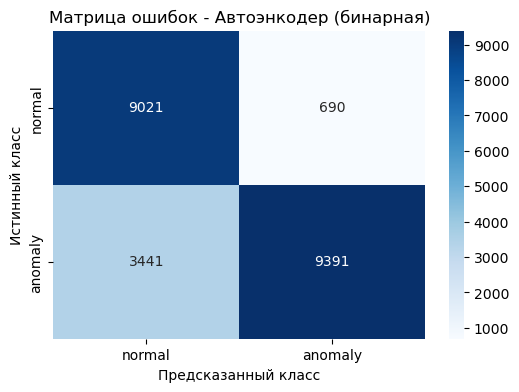


Accuracy для Автоэнкодера (бинарная): 0.8168

Типы атак, обнаруженные автоэнкодером как аномалии:
true_category_text
dos       6565
probe     2314
normal     690
r2l        501
u2r         11
Name: count, dtype: int64

Количество False Positives (нормальный трафик, помеченный как аномалия): 690


In [44]:
# Получаем ошибки реконструкции на обучающих нормальных данных (использованных для валидации во время fit)
# или на отдельной валидационной выборке нормальных данных
# Для простоты сейчас используем часть X_train_normal_ae, которая не пошла на валидацию при fit,
# или можно взять все X_train_normal_ae, если early_stopping не сильно переобучил.
# Лучше всего иметь отдельный валидационный набор нормальных данных.

# Пока для примера возьмем ошибки на тех же данных, что использовались для обучения (X_train_normal_ae)
# В идеале, нужно иметь отдельный набор нормальных данных для калибровки порога
train_normal_predictions = autoencoder.predict(X_train_normal_ae)
train_normal_mse = np.mean(np.power(X_train_normal_ae - train_normal_predictions, 2), axis=1)

# Определяем порог (например, 95-й или 99-й перцентиль ошибок на нормальных данных)
threshold = np.percentile(train_normal_mse, 99) # 99-й перцентиль как порог
print(f"Выбранный порог ошибки реконструкции: {threshold:.6f}")

# Теперь применяем к тестовым данным (X_test_final)
test_predictions = autoencoder.predict(X_test_final)
test_mse = np.mean(np.power(X_test_final.to_numpy() - test_predictions, 2), axis=1) # .to_numpy() если X_test_final это DataFrame

# Классифицируем как аномалию, если ошибка выше порога
# 0 - normal (ошибка <= порога), 1 - anomaly (ошибка > порога)
y_pred_ae_binary = (test_mse > threshold).astype(int)

# Нам нужно сравнить это с нашими истинными метками.
# Истинные метки у нас многоклассовые. Преобразуем их в бинарные: 0 (normal) и 1 (любая атака)
y_test_binary = (y_test_encoded != normal_class_code).astype(int) # normal_class_code мы определили ранее

print("\nОтчет по классификации для Автоэнкодера (бинарная, на тестовых данных):")
print(classification_report(y_test_binary, y_pred_ae_binary, target_names=['normal', 'anomaly']))

print("\nМатрица ошибок для Автоэнкодера (бинарная, на тестовых данных):")
cm_ae = confusion_matrix(y_test_binary, y_pred_ae_binary)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_ae, annot=True, fmt='d', cmap='Blues', xticklabels=['normal', 'anomaly'], yticklabels=['normal', 'anomaly'])
plt.title('Матрица ошибок - Автоэнкодер (бинарная)')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

print(f"\nAccuracy для Автоэнкодера (бинарная): {accuracy_score(y_test_binary, y_pred_ae_binary):.4f}")

# Можно также посмотреть, какие типы атак он обнаруживает как аномалии
# Создадим DataFrame с истинными категориями атак и предсказаниями автоэнкодера
results_ae = pd.DataFrame({'true_category_encoded': y_test_encoded,
                           'true_category_text': label_encoder_y.inverse_transform(y_test_encoded),
                           'ae_prediction_binary': y_pred_ae_binary,
                           'reconstruction_error': test_mse})

# Аномалии, обнаруженные автоэнкодером
detected_anomalies_ae = results_ae[results_ae['ae_prediction_binary'] == 1]
print("\nТипы атак, обнаруженные автоэнкодером как аномалии:")
print(detected_anomalies_ae['true_category_text'].value_counts())

# Нормальный трафик, ошибочно принятый за аномалию (False Positives)
fp_ae = results_ae[(results_ae['true_category_text'] == 'normal') & (results_ae['ae_prediction_binary'] == 1)]
print(f"\nКоличество False Positives (нормальный трафик, помеченный как аномалия): {len(fp_ae)}")